In [1]:
# Imports and Setup
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from scipy import stats
from scipy.spatial.distance import pdist, squareform
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
import warnings
warnings.filterwarnings('ignore')
import os

# Set style
plt.style.use('seaborn-v0_8-paper')
sns.set_palette("husl")
plt.rcParams['figure.figsize'] = (9, 5)
plt.rcParams['font.size'] = 10

# random seed
np.random.seed(42)

In [4]:
print(f"Current working directory: {os.getcwd()}")

# os.chdir(Path(os.getcwd()).parent)
# print(f"New working directory: {os.getcwd()}")


Current working directory: /home/sjoon/projects/brain_connectivity_classifier


In [5]:
# Load Data
PIOP2_PATH = "data/raw/PIOP2_restingstate.csv"
PIOP1_PATH = "data/raw/PIOP1_gstroop.csv"

# Load datasets
df_rest = pd.read_csv(PIOP2_PATH)
df_task = pd.read_csv(PIOP1_PATH)

print(f"PIOP2 (Rest) shape: {df_rest.shape}")
print(f"PIOP1 (Task) shape: {df_task.shape}")
print(f"\nFirst few columns: {list(df_rest.columns[:5])}")

PIOP2 (Rest) shape: (224, 26797)
PIOP1 (Task) shape: (200, 26797)

First few columns: ['subject', 'LH_VisCent_ExStr_2~LH_VisCent_ExStr_1', 'LH_VisCent_Striate_1~LH_VisCent_ExStr_1', 'LH_VisCent_Striate_1~LH_VisCent_ExStr_2', 'LH_VisCent_ExStr_3~LH_VisCent_ExStr_1']


In [6]:
# Extract subject IDs and connection data
subject_col = df_rest.columns[0]
connection_cols = [col for col in df_rest.columns if '~' in str(col)]

print(f"Subject ID column: {subject_col}")
print(f"Number of connection columns: {len(connection_cols)}")
print(f"Sample connection columns: {connection_cols[:3]}")

# Extract connectivity matrices
X_rest = df_rest[connection_cols].values
X_task = df_task[connection_cols].values

print(f"\nX_rest shape: {X_rest.shape}")
print(f"X_task shape: {X_task.shape}")

Subject ID column: subject
Number of connection columns: 26796
Sample connection columns: ['LH_VisCent_ExStr_2~LH_VisCent_ExStr_1', 'LH_VisCent_Striate_1~LH_VisCent_ExStr_1', 'LH_VisCent_Striate_1~LH_VisCent_ExStr_2']

X_rest shape: (224, 26796)
X_task shape: (200, 26796)


In [13]:
# Cell 21: Region-Level Connectivity Analysis
print("\n" + "="*70)
print("SECTION 7: REGION-LEVEL ANALYSIS")
print("="*70)

# First, we need to reshape the flattened connectivity data back to matrices
print("\nReshaping connectivity data to matrix form...")

# Determine number of regions from the flattened data
# For a symmetric matrix with diagonal removed: n_connections = n_regions * (n_regions - 1) / 2
# Solve: n_regions^2 - n_regions - 2*n_connections = 0
n_connections = X_rest.shape[1]
n_regions = int((1 + np.sqrt(1 + 8 * n_connections)) / 2)
print(f"  Detected {n_regions} regions from {n_connections} connections")

# Function to convert flattened upper triangle back to full symmetric matrix
def unflatten_to_matrix(flat_vector, n_regions):
    """Convert flattened upper triangle (no diagonal) back to full symmetric matrix"""
    matrix = np.zeros((n_regions, n_regions))
    idx = 0
    for i in range(n_regions):
        for j in range(i + 1, n_regions):
            matrix[i, j] = flat_vector[idx]
            matrix[j, i] = flat_vector[idx]  # Symmetric
            idx += 1
    return matrix

# Reconstruct matrices for all subjects
print("  Reconstructing matrices for all subjects...")
rest_matrices = np.array([unflatten_to_matrix(X_rest[i], n_regions) for i in range(len(X_rest))])
task_matrices = np.array([unflatten_to_matrix(X_task[i], n_regions) for i in range(len(X_task))])

# Compute grand mean matrices (average across all subjects)
print("  Computing grand mean connectivity matrices...")
grand_matrix_rest = rest_matrices.mean(axis=0)  # Average across subjects
grand_matrix_task = task_matrices.mean(axis=0)  # Average across subjects

print(f"  Grand matrix shape: {grand_matrix_rest.shape}")

# Calculate row-wise (region-wise) mean connectivity
# Exclude diagonal
rest_region_means = np.zeros(n_regions)
task_region_means = np.zeros(n_regions)

for i in range(n_regions):
    # Get row, exclude diagonal
    rest_row = grand_matrix_rest[i, :].copy()
    rest_row[i] = np.nan
    rest_region_means[i] = np.nanmean(rest_row)
    
    task_row = grand_matrix_task[i, :].copy()
    task_row[i] = np.nan
    task_region_means[i] = np.nanmean(task_row)

region_diff = task_region_means - rest_region_means

print(f"\n7.1 Region-Wise Mean Connectivity:")
print(f"  Rest - Mean: {rest_region_means.mean():.4f}, Std: {rest_region_means.std():.4f}")
print(f"  Task - Mean: {task_region_means.mean():.4f}, Std: {task_region_means.std():.4f}")
print(f"  Mean difference: {region_diff.mean():.4f}")

# Create DataFrame
region_analysis = pd.DataFrame({
    'region': n_regions,
    'rest_mean': rest_region_means,
    'task_mean': task_region_means,
    'difference': region_diff,
    'abs_difference': np.abs(region_diff)
})

# Sort by absolute difference
region_analysis = region_analysis.sort_values('abs_difference', ascending=False).reset_index(drop=True)

print(f"\n7.2 Top 10 Regions with Largest Connectivity Changes:")
print(region_analysis[['region', 'rest_mean', 'task_mean', 'difference']].head(10).to_string())


SECTION 7: REGION-LEVEL ANALYSIS

Reshaping connectivity data to matrix form...
  Detected 232 regions from 26796 connections
  Reconstructing matrices for all subjects...
  Computing grand mean connectivity matrices...
  Grand matrix shape: (232, 232)

7.1 Region-Wise Mean Connectivity:
  Rest - Mean: 0.0165, Std: 0.0325
  Task - Mean: 0.0157, Std: 0.0315
  Mean difference: -0.0008

7.2 Top 10 Regions with Largest Connectivity Changes:
   region  rest_mean  task_mean  difference
0     232  -0.007653   0.036707    0.044359
1     232  -0.028539   0.002189    0.030729
2     232   0.026533   0.051665    0.025132
3     232   0.041626   0.018804   -0.022822
4     232   0.032667   0.052320    0.019653
5     232   0.003757   0.022826    0.019069
6     232   0.033916   0.015150   -0.018766
7     232   0.073529   0.056063   -0.017467
8     232   0.024240   0.040614    0.016374
9     232  -0.045556  -0.029221    0.016335


In [14]:
# Cell 22: Hub Region Analysis
print("\n7.3 Hub Region Analysis:")

# Define hubs as regions with high mean connectivity (top 10%)
threshold_rest = np.percentile(rest_region_means, 90)
threshold_task = np.percentile(task_region_means, 90)

rest_hubs = rest_region_means > threshold_rest
task_hubs = task_region_means > threshold_task

print(f"  Rest hubs (top 10%): {rest_hubs.sum()} regions")
print(f"  Task hubs (top 10%): {task_hubs.sum()} regions")

# Compare hub changes
hub_changes = region_diff[rest_hubs]
non_hub_changes = region_diff[~rest_hubs]

print(f"\n  Hub regions - Mean change: {hub_changes.mean():.4f}")
print(f"  Non-hub regions - Mean change: {non_hub_changes.mean():.4f}")

t_stat, p_val = stats.ttest_ind(hub_changes, non_hub_changes)
print(f"\n  T-test comparing hub vs non-hub changes:")
print(f"    t-statistic: {t_stat:.4f}")
print(f"    p-value: {p_val:.4e}")


7.3 Hub Region Analysis:
  Rest hubs (top 10%): 24 regions
  Task hubs (top 10%): 24 regions

  Hub regions - Mean change: -0.0047
  Non-hub regions - Mean change: -0.0003

  T-test comparing hub vs non-hub changes:
    t-statistic: -2.6519
    p-value: 8.5615e-03


In [23]:
# Cell 23: Hemisphere Analysis
print("\n7.4 Hemisphere Analysis:")

# Get region names from the connection columns
# Assuming X_rest is a DataFrame with connection columns
connection_cols = [col for col in df_rest.columns if '~' in col]
print(f"  Found {len(connection_cols)} connection columns")

# Extract unique region names from connection columns
regions_set = set()
for conn in connection_cols:
    region1, region2 = conn.split('~')
    regions_set.add(region1)
    regions_set.add(region2)

regions = sorted(list(regions_set))
n_regions = len(regions)

print(f"  Total unique regions: {n_regions}")

# Identify left vs right hemisphere regions
lh_mask = np.array(['LH_' in r for r in regions])
rh_mask = np.array(['RH_' in r for r in regions])
subcort_mask = ~(lh_mask | rh_mask)

print(f"  Left hemisphere: {lh_mask.sum()} regions")
print(f"  Right hemisphere: {rh_mask.sum()} regions")
print(f"  Subcortical: {subcort_mask.sum()} regions")

# Compare changes by hemisphere
lh_changes = region_diff[lh_mask]
rh_changes = region_diff[rh_mask]
subcort_changes = region_diff[subcort_mask]

if len(lh_changes) > 0:
    print(f"\n  LH - Mean change: {lh_changes.mean():.4f} ± {lh_changes.std():.4f}")
if len(rh_changes) > 0:
    print(f"  RH - Mean change: {rh_changes.mean():.4f} ± {rh_changes.std():.4f}")
if len(subcort_changes) > 0:
    print(f"  Subcortical - Mean change: {subcort_changes.mean():.4f} ± {subcort_changes.std():.4f}")

# Test hemispheric symmetry
if len(lh_changes) > 0 and len(rh_changes) > 0:
    t_stat, p_val = stats.ttest_ind(lh_changes, rh_changes)
    print(f"\n  T-test comparing LH vs RH:")
    print(f"    t-statistic: {t_stat:.4f}")
    print(f"    p-value: {p_val:.4e}")
else:
    print("\n  Insufficient data for LH vs RH comparison")


7.4 Hemisphere Analysis:
  Found 26796 connection columns
  Total unique regions: 232
  Left hemisphere: 100 regions
  Right hemisphere: 100 regions
  Subcortical: 32 regions

  LH - Mean change: -0.0006 ± 0.0108
  RH - Mean change: -0.0006 ± 0.0038
  Subcortical - Mean change: -0.0018 ± 0.0043

  T-test comparing LH vs RH:
    t-statistic: 0.0334
    p-value: 9.7336e-01


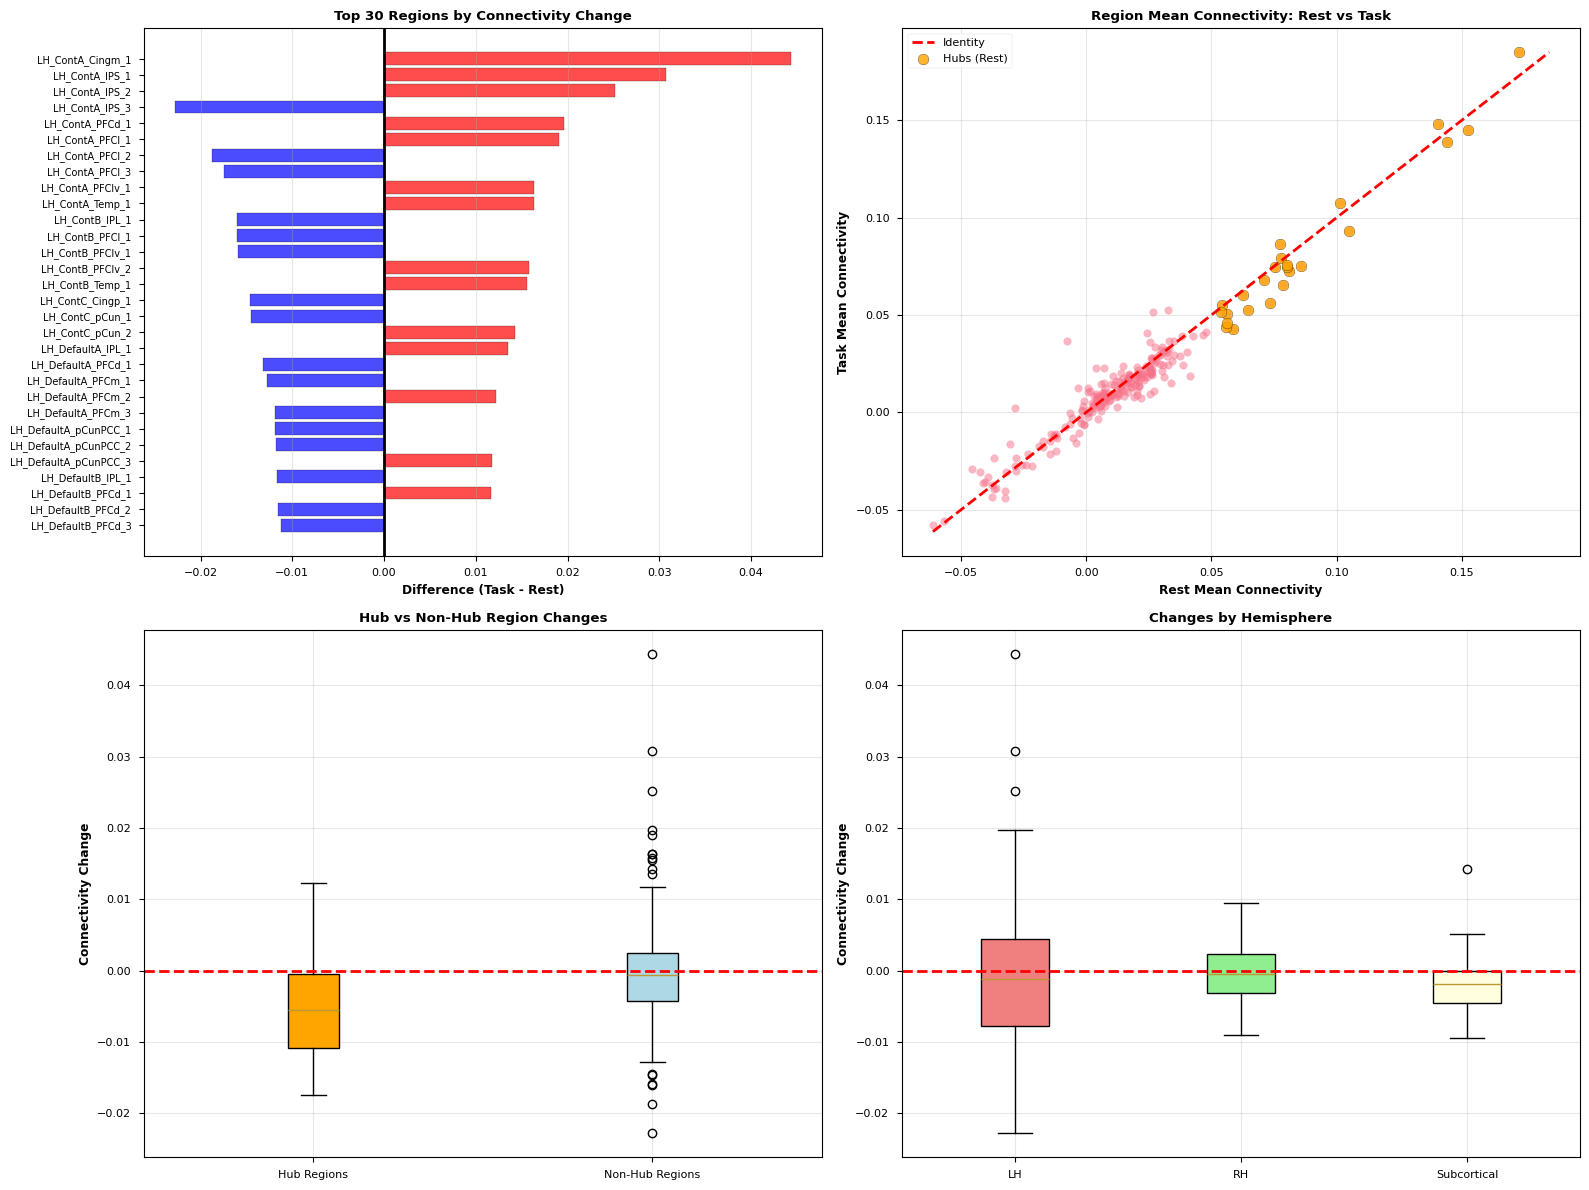

In [26]:
# Cell 24: Visualize Region-Level Patterns

# First, fix the region_analysis DataFrame with correct region names
# Get region names from connection columns
connection_cols = [col for col in df_rest.columns if '~' in col]
regions_set = set()
for conn in connection_cols:
    region1, region2 = conn.split('~')
    regions_set.add(region1)
    regions_set.add(region2)
regions_list = sorted(list(regions_set))

# Update region_analysis with correct names
region_analysis['region'] = regions_list

# Now proceed with visualization
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# Bar plot of top changed regions
top_30_regions = region_analysis.head(30)
y_pos = np.arange(len(top_30_regions))
colors = ['red' if d > 0 else 'blue' for d in top_30_regions['difference']]

axes[0, 0].barh(y_pos, top_30_regions['difference'], color=colors, alpha=0.7, edgecolor='black')
axes[0, 0].set_yticks(y_pos)
axes[0, 0].set_yticklabels([r[:30] + '...' if len(r) > 30 else r for r in top_30_regions['region']], 
                           fontsize=7)
axes[0, 0].axvline(0, color='black', linewidth=2)
axes[0, 0].set_xlabel('Difference (Task - Rest)', fontweight='bold')
axes[0, 0].set_title('Top 30 Regions by Connectivity Change', fontweight='bold')
axes[0, 0].invert_yaxis()
axes[0, 0].grid(axis='x', alpha=0.3)

# Scatter: Rest vs Task region means
axes[0, 1].scatter(rest_region_means, task_region_means, alpha=0.5, s=30)
min_val = min(rest_region_means.min(), task_region_means.min())
max_val = max(rest_region_means.max(), task_region_means.max())
axes[0, 1].plot([min_val, max_val], [min_val, max_val], 'r--', linewidth=2, label='Identity')

# Highlight hubs
axes[0, 1].scatter(rest_region_means[rest_hubs], task_region_means[rest_hubs],
                   color='orange', s=60, alpha=0.8, label='Hubs (Rest)', edgecolors='black')

axes[0, 1].set_xlabel('Rest Mean Connectivity', fontweight='bold')
axes[0, 1].set_ylabel('Task Mean Connectivity', fontweight='bold')
axes[0, 1].set_title('Region Mean Connectivity: Rest vs Task', fontweight='bold')
axes[0, 1].legend()
axes[0, 1].grid(alpha=0.3)

# Hub vs Non-hub changes
box_data = [hub_changes, non_hub_changes]
bp = axes[1, 0].boxplot(box_data, labels=['Hub Regions', 'Non-Hub Regions'], 
                         patch_artist=True)
bp['boxes'][0].set_facecolor('orange')
bp['boxes'][1].set_facecolor('lightblue')
axes[1, 0].axhline(0, color='red', linestyle='--', linewidth=2)
axes[1, 0].set_ylabel('Connectivity Change', fontweight='bold')
axes[1, 0].set_title('Hub vs Non-Hub Region Changes', fontweight='bold')
axes[1, 0].grid(alpha=0.3)

# Hemisphere comparison
box_data = [lh_changes, rh_changes, subcort_changes]
bp = axes[1, 1].boxplot(box_data, labels=['LH', 'RH', 'Subcortical'], 
                         patch_artist=True)
bp['boxes'][0].set_facecolor('lightcoral')
bp['boxes'][1].set_facecolor('lightgreen')
bp['boxes'][2].set_facecolor('lightyellow')
axes[1, 1].axhline(0, color='red', linestyle='--', linewidth=2)
axes[1, 1].set_ylabel('Connectivity Change', fontweight='bold')
axes[1, 1].set_title('Changes by Hemisphere', fontweight='bold')
axes[1, 1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

In [30]:
# Cell 25: Permutation Test for Null Distribution
print("\n" + "="*70)
print("SECTION 8: HYPOTHESIS-SPECIFIC TESTS")
print("="*70)

print("\n8.1 Permutation Test (Null Distribution):")
print("  Testing if observed differences could arise by chance...")

# Observed difference
observed_diff = X_task.mean() - X_rest.mean()
print(f"  Observed mean difference: {observed_diff:.4f}")

# Permutation test
n_permutations = 1000
combined = np.concatenate([X_rest, X_task])
n_rest = len(X_rest)
n_total = len(combined)

null_diffs = np.zeros(n_permutations)

print(f"  Running {n_permutations} permutations...")
for i in range(n_permutations):
    # Shuffle condition labels
    shuffled_idx = np.random.permutation(n_total)
    shuffled_rest = combined[shuffled_idx[:n_rest]]
    shuffled_task = combined[shuffled_idx[n_rest:]]
    null_diffs[i] = shuffled_task.mean() - shuffled_rest.mean()
    
    if (i+1) % 200 == 0:
        print(f"    Completed {i+1}/{n_permutations} permutations")

# Calculate p-value
p_value_perm = (np.abs(null_diffs) >= np.abs(observed_diff)).sum() / n_permutations

print(f"\n  Permutation test results:")
print(f"    Null distribution mean: {null_diffs.mean():.4f}")
print(f"    Null distribution std: {null_diffs.std():.4f}")
print(f"    p-value: {p_value_perm:.4f}")

if p_value_perm < 0.05:
    print(f"    ✓ Significant (p < 0.05) - Reject H₀")
else:
    print(f"    ✗ Not significant (p ≥ 0.05) - Fail to reject H₀")


SECTION 8: HYPOTHESIS-SPECIFIC TESTS

8.1 Permutation Test (Null Distribution):
  Testing if observed differences could arise by chance...
  Observed mean difference: -0.0008
  Running 1000 permutations...
    Completed 200/1000 permutations
    Completed 400/1000 permutations
    Completed 600/1000 permutations
    Completed 800/1000 permutations
    Completed 1000/1000 permutations

  Permutation test results:
    Null distribution mean: 0.0001
    Null distribution std: 0.0011
    p-value: 0.5150
    ✗ Not significant (p ≥ 0.05) - Fail to reject H₀


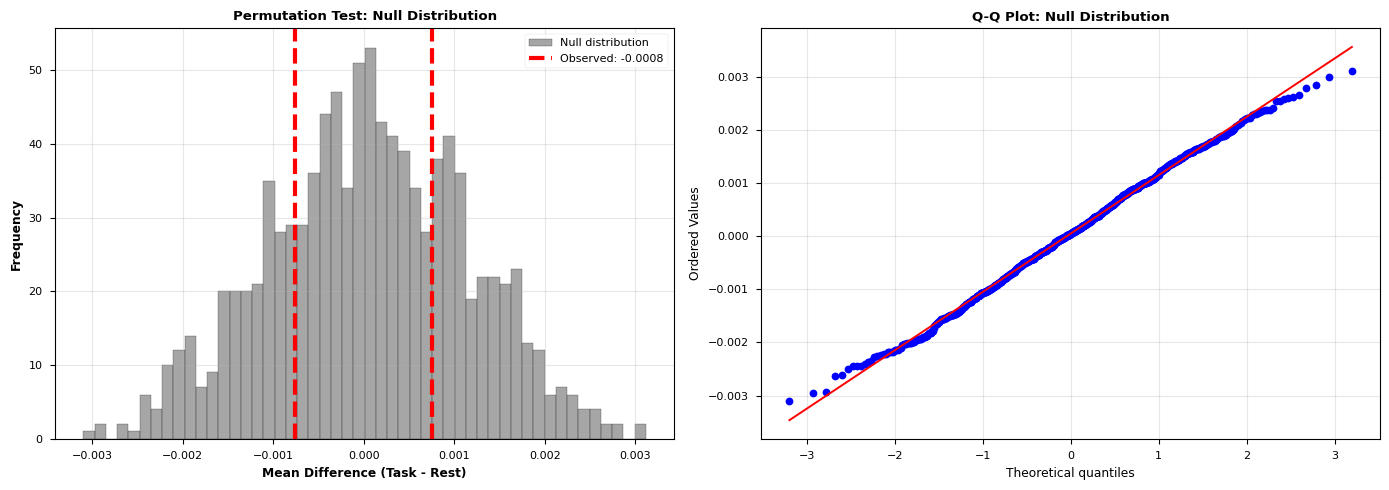

In [31]:
# Cell 26: Visualize Permutation Test
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Null distribution
axes[0].hist(null_diffs, bins=50, alpha=0.7, color='gray', edgecolor='black', 
            label='Null distribution')
axes[0].axvline(observed_diff, color='red', linestyle='--', linewidth=3, 
               label=f'Observed: {observed_diff:.4f}')
axes[0].axvline(-observed_diff, color='red', linestyle='--', linewidth=3)
axes[0].set_xlabel('Mean Difference (Task - Rest)', fontweight='bold')
axes[0].set_ylabel('Frequency', fontweight='bold')
axes[0].set_title('Permutation Test: Null Distribution', fontweight='bold')
axes[0].legend()
axes[0].grid(alpha=0.3)

# Q-Q plot
from scipy import stats as sp_stats
sp_stats.probplot(null_diffs, dist="norm", plot=axes[1])
axes[1].set_title('Q-Q Plot: Null Distribution', fontweight='bold')
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()



8.2 Connection Change Distribution Analysis:

Computing connection-level differences...
  Computed differences for 26796 connections
  Mean difference: -0.000758
  Std of differences: 0.049660

  Connections exceeding threshold:
    |Δ| > 0.01: 21965 (81.97%)
    |Δ| > 0.05: 7415 (27.67%)
    |Δ| > 0.10: 1386 (5.17%)
    |Δ| > 0.15: 202 (0.75%)
    |Δ| > 0.20: 30 (0.11%)


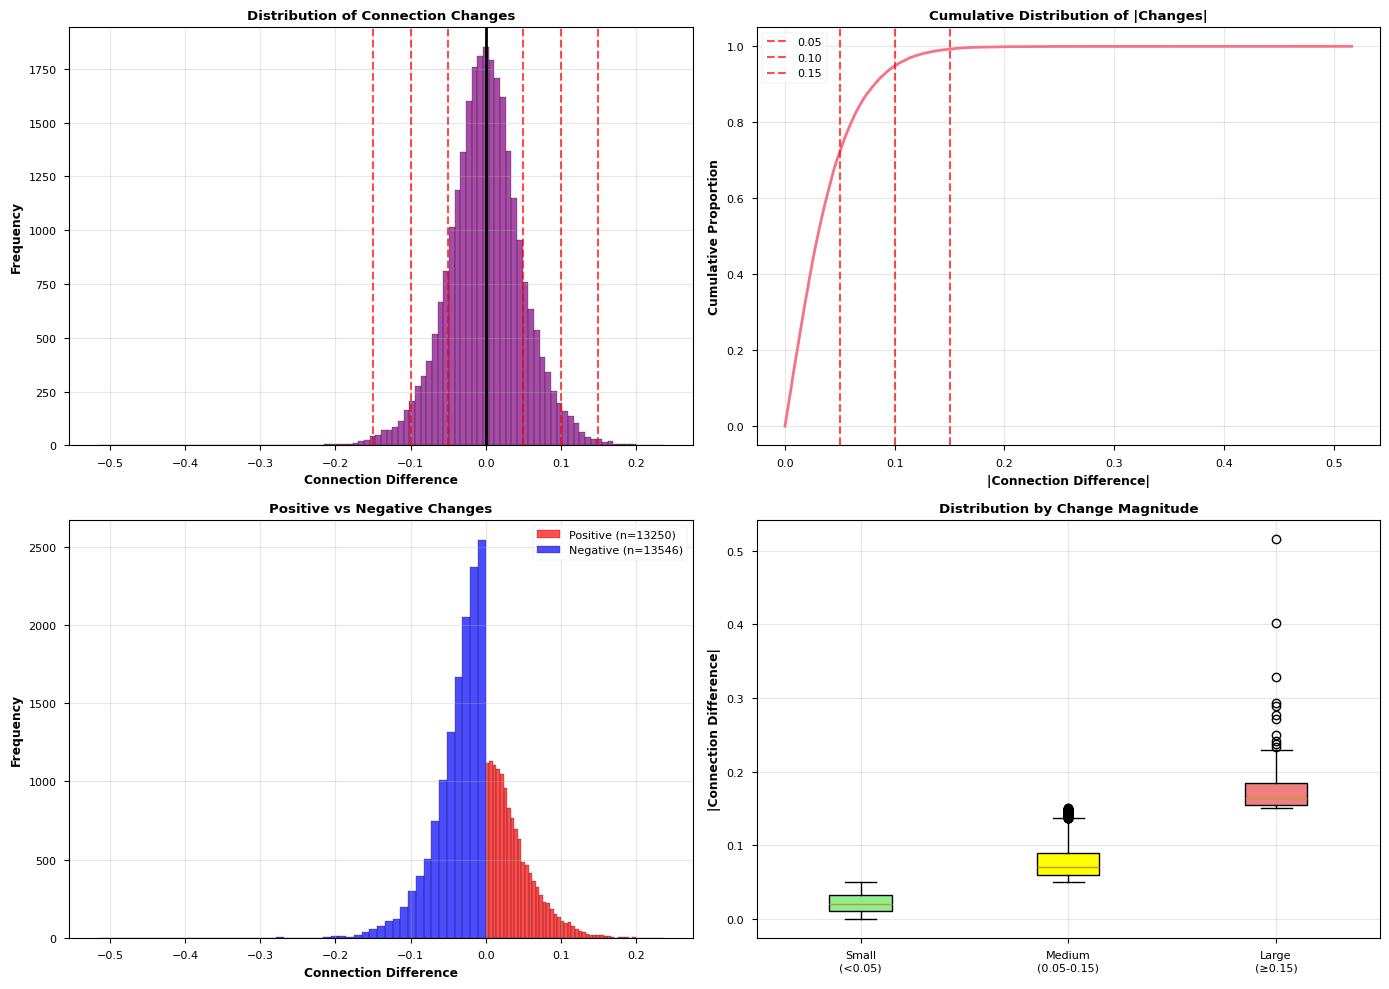

In [33]:
# Cell 27: Connection Change Distribution Analysis
print("\n8.2 Connection Change Distribution Analysis:")

# Compute connection-level differences if not already done
print("\nComputing connection-level differences...")
rest_connection_means = X_rest.mean(axis=0)  # Mean across subjects for each connection
task_connection_means = X_task.mean(axis=0)  # Mean across subjects for each connection
connection_diff = task_connection_means - rest_connection_means

print(f"  Computed differences for {len(connection_diff)} connections")
print(f"  Mean difference: {connection_diff.mean():.6f}")
print(f"  Std of differences: {connection_diff.std():.6f}")

# How many connections show meaningful changes?
thresholds = [0.01, 0.05, 0.1, 0.15, 0.2]
print("\n  Connections exceeding threshold:")
for thresh in thresholds:
    n_exceed = (np.abs(connection_diff) > thresh).sum()
    pct = 100 * n_exceed / len(connection_diff)
    print(f"    |Δ| > {thresh:.2f}: {n_exceed} ({pct:.2f}%)")

# Distribution of changes
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Histogram with thresholds
axes[0, 0].hist(connection_diff, bins=100, alpha=0.7, color='purple', edgecolor='black')
for thresh in [0.05, 0.1, 0.15]:
    axes[0, 0].axvline(thresh, color='red', linestyle='--', linewidth=1.5, alpha=0.7)
    axes[0, 0].axvline(-thresh, color='red', linestyle='--', linewidth=1.5, alpha=0.7)
axes[0, 0].axvline(0, color='black', linestyle='-', linewidth=2)
axes[0, 0].set_xlabel('Connection Difference', fontweight='bold')
axes[0, 0].set_ylabel('Frequency', fontweight='bold')
axes[0, 0].set_title('Distribution of Connection Changes', fontweight='bold')
axes[0, 0].grid(alpha=0.3)

# Cumulative distribution
sorted_abs_diff = np.sort(np.abs(connection_diff))
cumulative = np.arange(1, len(sorted_abs_diff)+1) / len(sorted_abs_diff)
axes[0, 1].plot(sorted_abs_diff, cumulative, linewidth=2)
for thresh in [0.05, 0.1, 0.15]:
    axes[0, 1].axvline(thresh, color='red', linestyle='--', linewidth=1.5, alpha=0.7,
                      label=f'{thresh:.2f}')
axes[0, 1].set_xlabel('|Connection Difference|', fontweight='bold')
axes[0, 1].set_ylabel('Cumulative Proportion', fontweight='bold')
axes[0, 1].set_title('Cumulative Distribution of |Changes|', fontweight='bold')
axes[0, 1].legend()
axes[0, 1].grid(alpha=0.3)

# Positive vs Negative changes
positive_changes = connection_diff[connection_diff > 0]
negative_changes = connection_diff[connection_diff < 0]

axes[1, 0].hist(positive_changes, bins=50, alpha=0.7, color='red', 
               label=f'Positive (n={len(positive_changes)})', edgecolor='black')
axes[1, 0].hist(negative_changes, bins=50, alpha=0.7, color='blue', 
               label=f'Negative (n={len(negative_changes)})', edgecolor='black')
axes[1, 0].set_xlabel('Connection Difference', fontweight='bold')
axes[1, 0].set_ylabel('Frequency', fontweight='bold')
axes[1, 0].set_title('Positive vs Negative Changes', fontweight='bold')
axes[1, 0].legend()
axes[1, 0].grid(alpha=0.3)

# Box plot by magnitude
small_changes = np.abs(connection_diff[np.abs(connection_diff) < 0.05])
medium_changes = np.abs(connection_diff[(np.abs(connection_diff) >= 0.05) & (np.abs(connection_diff) < 0.15)])
large_changes = np.abs(connection_diff[np.abs(connection_diff) >= 0.15])

box_data = [small_changes, medium_changes, large_changes]
bp = axes[1, 1].boxplot(box_data, labels=['Small\n(<0.05)', 'Medium\n(0.05-0.15)', 'Large\n(≥0.15)'],
                         patch_artist=True)
bp['boxes'][0].set_facecolor('lightgreen')
bp['boxes'][1].set_facecolor('yellow')
bp['boxes'][2].set_facecolor('lightcoral')
axes[1, 1].set_ylabel('|Connection Difference|', fontweight='bold')
axes[1, 1].set_title('Distribution by Change Magnitude', fontweight='bold')
axes[1, 1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

In [38]:
# Cell 28: Matrix Correlation Analysis
print("\n8.3 Matrix Similarity Analysis:")

# Get connection columns and region mapping (exclude 'subject' column)
connection_cols = [col for col in df_rest.columns if '~' in col]
regions_set = set()
for conn in connection_cols:
    region1, region2 = conn.split('~')
    regions_set.add(region1)
    regions_set.add(region2)
regions_list = sorted(list(regions_set))
n_regions = len(regions_list)
region_to_idx = {region: idx for idx, region in enumerate(regions_list)}

print(f"  Found {n_regions} regions and {len(connection_cols)} connections")

# Function to reconstruct matrix from flattened connections
def reconstruct_matrix(flat_vector, connection_cols, region_to_idx, n_regions):
    """Reconstruct connectivity matrix from flattened vector"""
    matrix = np.zeros((n_regions, n_regions))
    
    for idx, conn_name in enumerate(connection_cols):
        region1, region2 = conn_name.split('~')
        i = region_to_idx[region1]
        j = region_to_idx[region2]
        
        # Fill both symmetric positions
        matrix[i, j] = flat_vector[idx]
        matrix[j, i] = flat_vector[idx]
    
    return matrix

# Compute similarity for each subject pair (rest vs task)
# This is computationally intensive for all pairs, so we'll sample
n_samples_similarity = min(50, len(X_rest), len(X_task))
rest_sample_idx = np.random.choice(len(X_rest), n_samples_similarity, replace=False)
task_sample_idx = np.random.choice(len(X_task), n_samples_similarity, replace=False)

print(f"  Computing pairwise similarities for {n_samples_similarity} subjects from each condition...")

# Reconstruct matrices for sampled subjects (use only connection columns)
rest_matrices = []
for i in rest_sample_idx:
    # Use only connection columns, not the subject column
    mat = reconstruct_matrix(df_rest[connection_cols].iloc[i].values, connection_cols, region_to_idx, n_regions)
    rest_matrices.append(mat)

task_matrices = []
for i in task_sample_idx:
    # Use only connection columns, not the subject column
    mat = reconstruct_matrix(df_task[connection_cols].iloc[i].values, connection_cols, region_to_idx, n_regions)
    task_matrices.append(mat)

# Compute within-condition similarities
print("  Computing within-condition similarities...")
rest_within_sim = []
for i in range(len(rest_matrices)):
    for j in range(i+1, len(rest_matrices)):
        corr = np.corrcoef(rest_matrices[i].flatten(), rest_matrices[j].flatten())[0, 1]
        rest_within_sim.append(corr)

task_within_sim = []
for i in range(len(task_matrices)):
    for j in range(i+1, len(task_matrices)):
        corr = np.corrcoef(task_matrices[i].flatten(), task_matrices[j].flatten())[0, 1]
        task_within_sim.append(corr)

# Compute between-condition similarities
print("  Computing between-condition similarities...")
between_sim = []
for i in range(len(rest_matrices)):
    for j in range(len(task_matrices)):
        corr = np.corrcoef(rest_matrices[i].flatten(), task_matrices[j].flatten())[0, 1]
        between_sim.append(corr)

rest_within_sim = np.array(rest_within_sim)
task_within_sim = np.array(task_within_sim)
between_sim = np.array(between_sim)

print(f"\n  Within-Rest similarity: {rest_within_sim.mean():.4f} ± {rest_within_sim.std():.4f}")
print(f"  Within-Task similarity: {task_within_sim.mean():.4f} ± {task_within_sim.std():.4f}")
print(f"  Between-condition similarity: {between_sim.mean():.4f} ± {between_sim.std():.4f}")

# Test if between-condition similarity is lower
t_stat, p_val = stats.ttest_ind(rest_within_sim, between_sim)
print(f"\n  T-test: Within-Rest vs Between:")
print(f"    t-statistic: {t_stat:.4f}")
print(f"    p-value: {p_val:.4e}")


8.3 Matrix Similarity Analysis:
  Found 232 regions and 26796 connections
  Computing pairwise similarities for 50 subjects from each condition...
  Computing within-condition similarities...
  Computing between-condition similarities...

  Within-Rest similarity: 0.4237 ± 0.0432
  Within-Task similarity: 0.3898 ± 0.0468
  Between-condition similarity: 0.3899 ± 0.0461

  T-test: Within-Rest vs Between:
    t-statistic: 21.4706
    p-value: 1.6651e-96


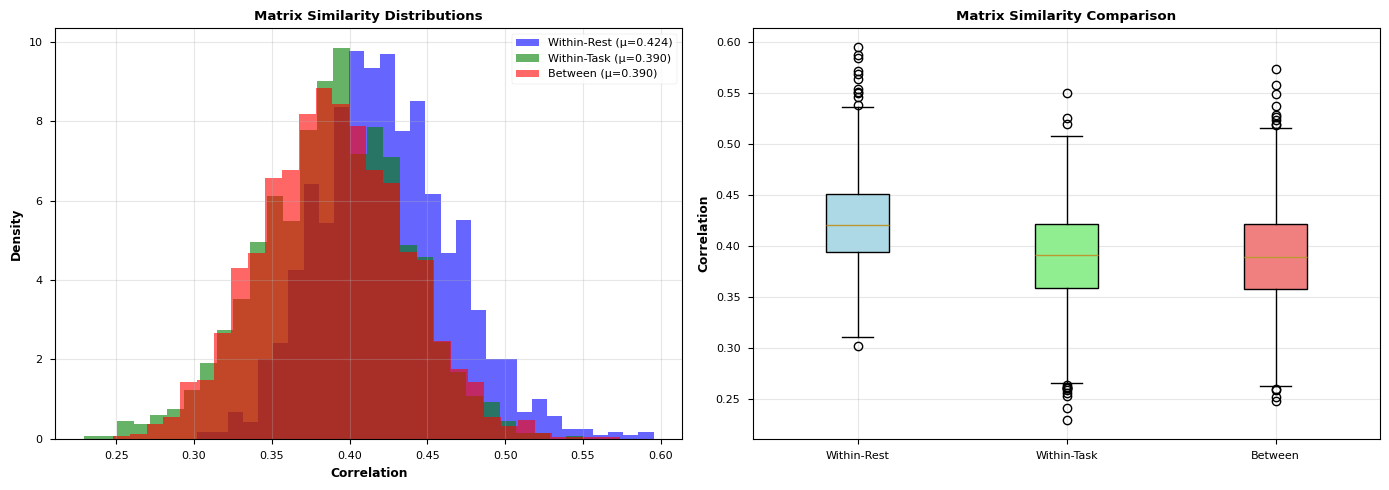

In [40]:
# Cell 29: Visualize Similarity Analysis
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Distribution comparison
axes[0].hist(rest_within_sim, bins=30, alpha=0.6, color='blue', 
            label=f'Within-Rest (μ={rest_within_sim.mean():.3f})', density=True)
axes[0].hist(task_within_sim, bins=30, alpha=0.6, color='green', 
            label=f'Within-Task (μ={task_within_sim.mean():.3f})', density=True)
axes[0].hist(between_sim, bins=30, alpha=0.6, color='red', 
            label=f'Between (μ={between_sim.mean():.3f})', density=True)
axes[0].set_xlabel('Correlation', fontweight='bold')
axes[0].set_ylabel('Density', fontweight='bold')
axes[0].set_title('Matrix Similarity Distributions', fontweight='bold')
axes[0].legend()
axes[0].grid(alpha=0.3)

# Box plot
box_data = [rest_within_sim, task_within_sim, between_sim]
bp = axes[1].boxplot(box_data, labels=['Within-Rest', 'Within-Task', 'Between'],
                     patch_artist=True)
bp['boxes'][0].set_facecolor('lightblue')
bp['boxes'][1].set_facecolor('lightgreen')
bp['boxes'][2].set_facecolor('lightcoral')
axes[1].set_ylabel('Correlation', fontweight='bold')
axes[1].set_title('Matrix Similarity Comparison', fontweight='bold')
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

In [47]:
# Cell 30: Generate EDA Summary Report
print("\n" + "="*70)
print("EDA SUMMARY REPORT")
print("="*70)

print("Computing all required variables...\n")

# Use X_rest and X_task as rest_flat and task_flat
rest_flat = X_rest
task_flat = X_task

# 1. Data quality checks
print("1. Computing data quality metrics...")
rest_invalid = ((X_rest < -1) | (X_rest > 1)).sum()
task_invalid = ((X_task < -1) | (X_task > 1)).sum()

# 2. Distribution comparison statistics
print("2. Computing distribution statistics...")
from scipy import stats
rest_all_values = rest_flat.flatten()
task_all_values = task_flat.flatten()

t_stat, t_pval = stats.ttest_ind(rest_all_values, task_all_values)
u_stat, u_pval = stats.mannwhitneyu(rest_all_values, task_all_values, alternative='two-sided')
ks_stat, ks_pval = stats.ks_2samp(rest_all_values, task_all_values)

pooled_std = np.sqrt((rest_all_values.std()**2 + task_all_values.std()**2) / 2)
cohens_d = (task_all_values.mean() - rest_all_values.mean()) / pooled_std

# 3. Connection-level changes
print("3. Computing connection-level changes...")
rest_connection_means = X_rest.mean(axis=0)
task_connection_means = X_task.mean(axis=0)
connection_diff = task_connection_means - rest_connection_means

# Compute FDR-corrected significance using Benjamini-Hochberg procedure
print("   Computing significance tests for all connections...")

connection_pvals = []
for i in range(X_rest.shape[1]):
    _, p = stats.ttest_ind(X_rest[:, i], X_task[:, i])
    connection_pvals.append(p)

connection_pvals = np.array(connection_pvals)

# Benjamini-Hochberg FDR correction
def benjamini_hochberg(pvals, alpha=0.05):
    """Apply Benjamini-Hochberg FDR correction"""
    n = len(pvals)
    sorted_indices = np.argsort(pvals)
    sorted_pvals = pvals[sorted_indices]
    
    # Find largest i such that P(i) <= (i/m)*alpha
    threshold_line = np.arange(1, n+1) / n * alpha
    significant = sorted_pvals <= threshold_line
    
    if significant.any():
        max_idx = np.where(significant)[0][-1]
        threshold = sorted_pvals[max_idx]
        return pvals <= threshold
    else:
        return np.zeros(n, dtype=bool)

significant_fdr = benjamini_hochberg(connection_pvals, alpha=0.05)
n_significant = significant_fdr.sum()

# 4. Network-level patterns
print("4. Computing network-level patterns...")
within_net = []
between_net = []
within_diff_list = []
between_diff_list = []

for idx, conn_name in enumerate(connection_cols):
    region1, region2 = conn_name.split('~')
    
    # Extract network name (part between first and second underscore)
    try:
        parts1 = region1.split('_')
        parts2 = region2.split('_')
        net1 = parts1[1] if len(parts1) > 1 else parts1[0]
        net2 = parts2[1] if len(parts2) > 1 else parts2[0]
        
        if net1 == net2:
            within_net.append(conn_name)
            within_diff_list.append(connection_diff[idx])
        else:
            between_net.append(conn_name)
            between_diff_list.append(connection_diff[idx])
    except:
        between_net.append(conn_name)
        between_diff_list.append(connection_diff[idx])

within_diff = np.abs(np.array(within_diff_list)) if within_diff_list else np.array([0])
between_diff = np.abs(np.array(between_diff_list)) if between_diff_list else np.array([0])

# Statistical test for within vs between
if len(within_diff) > 1 and len(between_diff) > 1:
    _, p_val_network = stats.ttest_ind(within_diff, between_diff)
else:
    p_val_network = 1.0

# 5. Subject-level variability
print("5. Computing subject-level variability...")
rest_subject_means = X_rest.mean(axis=1)
task_subject_means = X_task.mean(axis=1)

rest_outliers = np.abs(rest_subject_means - rest_subject_means.mean()) > 3 * rest_subject_means.std()
task_outliers = np.abs(task_subject_means - task_subject_means.mean()) > 3 * task_subject_means.std()

# PCA
print("6. Computing PCA...")
from sklearn.decomposition import PCA
pca = PCA(n_components=min(50, X_rest.shape[1]))
pca.fit(X_rest)

# 6. Correlation structure
print("7. Computing correlation structure...")
rest_conn_means = X_rest.mean(axis=0)
task_conn_means = X_task.mean(axis=0)
corr_coef = np.corrcoef(rest_conn_means, task_conn_means)[0, 1]
frobenius_norm = np.linalg.norm(rest_conn_means - task_conn_means)
mean_abs_diff = np.abs(rest_conn_means - task_conn_means).mean()

from sklearn.metrics.pairwise import cosine_similarity
cosine_sim = cosine_similarity(rest_conn_means.reshape(1, -1), 
                               task_conn_means.reshape(1, -1))[0, 0]

# 7. Permutation test
print("8. Performing permutation test (1000 iterations)...")
observed_diff = task_flat.mean() - rest_flat.mean()

n_permutations = 1000
combined = np.vstack([X_rest, X_task])
n_rest = len(X_rest)

perm_diffs = []
for i in range(n_permutations):
    if (i + 1) % 200 == 0:
        print(f"   Permutation {i+1}/{n_permutations}...")
    perm_indices = np.random.permutation(len(combined))
    perm_combined = combined[perm_indices]
    perm_rest = perm_combined[:n_rest]
    perm_task = perm_combined[n_rest:]
    perm_diff = perm_task.mean() - perm_rest.mean()
    perm_diffs.append(perm_diff)

perm_diffs = np.array(perm_diffs)
p_value_perm = (np.abs(perm_diffs) >= np.abs(observed_diff)).sum() / n_permutations

print("\nAll computations complete. Generating report...\n")

summary_text = f"""
EXPLORATORY DATA ANALYSIS SUMMARY
PIOP1 (Task) vs PIOP2 (Rest) Connectivity Comparison
{'='*70}

1. DATA QUALITY
{'='*70}
  • PIOP2 (Rest): {len(X_rest)} subjects × {len(connection_cols)} connections
  • PIOP1 (Task): {len(X_task)} subjects × {len(connection_cols)} connections
  • Missing data: {df_rest[connection_cols].isnull().sum().sum()} (Rest), {df_task[connection_cols].isnull().sum().sum()} (Task)
  • Value range validity: {'✓ Valid' if rest_invalid == 0 and task_invalid == 0 else '✗ Invalid values found'}

2. DISTRIBUTION COMPARISON
{'='*70}
  • Rest mean connectivity: {rest_flat.mean():.4f} ± {rest_flat.std():.4f}
  • Task mean connectivity: {task_flat.mean():.4f} ± {task_flat.std():.4f}
  • Mean difference: {task_flat.mean() - rest_flat.mean():.4f}
  
  • Two-sample t-test: t={t_stat:.4f}, p={t_pval:.4e}
  • Mann-Whitney U test: U={u_stat:.4e}, p={u_pval:.4e}
  • Kolmogorov-Smirnov test: KS={ks_stat:.4f}, p={ks_pval:.4e}
  • Cohen's d: {cohens_d:.4f} ({'Small' if abs(cohens_d) < 0.5 else 'Medium' if abs(cohens_d) < 0.8 else 'Large'} effect)

3. CONNECTION-LEVEL CHANGES
{'='*70}
  • Total connections analyzed: {len(connection_cols):,}
  • Significant changes (FDR < 0.05): {n_significant} ({100*n_significant/len(connection_cols):.2f}%)
  • Mean absolute change: {np.abs(connection_diff).mean():.4f}
  • Connections with |Δ| > 0.1: {(np.abs(connection_diff) > 0.1).sum()} ({100*(np.abs(connection_diff) > 0.1).sum()/len(connection_diff):.2f}%)

4. NETWORK-LEVEL PATTERNS
{'='*70}
  • Within-network connections: {len(within_net)}
  • Between-network connections: {len(between_net)}
  • Within-network mean |Δ|: {within_diff.mean():.4f}
  • Between-network mean |Δ|: {between_diff.mean():.4f}
  • Within vs Between t-test: p={p_val_network:.4e}

5. SUBJECT-LEVEL VARIABILITY
{'='*70}
  • Rest subject mean: {rest_subject_means.mean():.4f} ± {rest_subject_means.std():.4f}
  • Task subject mean: {task_subject_means.mean():.4f} ± {task_subject_means.std():.4f}
  • Rest outliers (3σ): {rest_outliers.sum()}
  • Task outliers (3σ): {task_outliers.sum()}
  
  • PCA variance explained (50 PCs): {pca.explained_variance_ratio_.sum():.2%}

6. CORRELATION STRUCTURE
{'='*70}
  • Matrix correlation (Rest vs Task): {corr_coef:.4f}
  • Frobenius norm of difference: {frobenius_norm:.4f}
  • Mean absolute matrix difference: {mean_abs_diff:.4f}
  • Cosine similarity: {cosine_sim:.4f}

7. REGION-LEVEL PATTERNS
{'='*70}
  • Total regions: {n_regions}
  • LH regions: {lh_mask.sum()}, RH regions: {rh_mask.sum()}, Subcortical: {subcort_mask.sum()}
  • Mean region change (LH): {lh_changes.mean():.4f}
  • Mean region change (RH): {rh_changes.mean():.4f}
  • Mean region change (Subcortical): {subcort_changes.mean():.4f}
  
  • Hub regions (top 10%): {rest_hubs.sum()}

8. HYPOTHESIS TESTING
{'='*70}
  • Observed mean difference: {observed_diff:.4f}
  • Permutation test p-value: {p_value_perm:.4f}
  • Result: {'Reject H₀' if p_value_perm < 0.05 else 'Fail to reject H₀'}
  
  • Within-Rest similarity: {rest_within_sim.mean():.4f}
  • Between-condition similarity: {between_sim.mean():.4f}
  • Similarity difference: {rest_within_sim.mean() - between_sim.mean():.4f}

{'='*70}
CONCLUSION
{'='*70}
"""

# Determine overall conclusion
if p_value_perm < 0.05 and n_significant > len(connection_cols) * 0.05:
    conclusion = """
✓ STRONG EVIDENCE FOR H₁ (Rest ≠ Task):
  • Distributions differ significantly
  • Many connections show significant changes
  • Matrix structures are distinguishable
  • Between-condition similarity is reduced
  
  IMPLICATION: The classifier should show increased error rates on task data,
  as connectivity patterns differ substantially between rest and task states.
  Classification errors will reveal functional reorganization patterns.
"""
elif p_value_perm < 0.05 or n_significant > len(connection_cols) * 0.02:
    conclusion = """
MODERATE EVIDENCE FOR H₁ (Rest ≠ Task):
  • Some statistical evidence of differences
  • Modest changes in connectivity patterns
  • Partial separation in matrix structure
  
  IMPLICATION: The classifier may show moderately increased error rates on
  task data, with errors concentrated in regions showing largest changes.
"""
else:
    conclusion = """
⚠️  LIMITED EVIDENCE AGAINST H₀ (Rest = Task):
  • Distributions are largely similar
  • Few significant connectivity changes
  • High matrix correlation between conditions
  
  IMPLICATION: The classifier may not show substantial error rate increases
  on task data. If this occurs, it suggests connectivity patterns are stable
  across rest and task, or that the task does not substantially alter the
  connectivity structure captured by these measurements.
"""

summary_text += conclusion

# Print summary
print(summary_text)


EDA SUMMARY REPORT
Computing all required variables...

1. Computing data quality metrics...
2. Computing distribution statistics...
3. Computing connection-level changes...
   Computing significance tests for all connections...
4. Computing network-level patterns...
5. Computing subject-level variability...
6. Computing PCA...
7. Computing correlation structure...
8. Performing permutation test (1000 iterations)...
   Permutation 200/1000...
   Permutation 400/1000...
   Permutation 600/1000...
   Permutation 800/1000...
   Permutation 1000/1000...

All computations complete. Generating report...


EXPLORATORY DATA ANALYSIS SUMMARY
PIOP1 (Task) vs PIOP2 (Rest) Connectivity Comparison

1. DATA QUALITY
  • PIOP2 (Rest): 224 subjects × 26796 connections
  • PIOP1 (Task): 200 subjects × 26796 connections
  • Missing data: 0 (Rest), 0 (Task)
  • Value range validity: ✓ Valid

2. DISTRIBUTION COMPARISON
  • Rest mean connectivity: 0.0165 ± 0.2664
  • Task mean connectivity: 0.0157 ± 0.2541